# Ontario Facility CO₂ Emissions Over Time (2010–2023)

**Data Visualization — Assignment 3 (Python portion)**

This notebook builds a single, accessible **bar chart** showing how Ontario's reported
facility-level **carbon dioxide (CO₂)** emissions have changed year by year from 2010 to
2023. Biogenic ("from biomass") CO₂ is excluded so the chart reflects anthropogenic CO₂
only.

**Dataset:** Greenhouse Gas Emissions Reporting By Facility — *2010–2023 Specified GHG Activities*,
Ontario Data Catalogue.
Link: https://data.ontario.ca/dataset/greenhouse-gas-emissions-reporting-by-facility/resource/0996bfd9-ed27-4f78-8ed1-9e024185f10a

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Render figures inline in the notebook.
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300          # high-resolution PNG export (rubric: high-res visuals)
plt.rcParams['font.size'] = 11

In [ ]:
# Loading the data. I do not know how to make this more reproducible in all honesty. 
DATA_PATH = "/Users/ethanchurchill/Desktop/Data Science visualization/02_activities/GHG emissions.csv"

df = pd.read_csv(DATA_PATH)

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (3806, 20)


,_id,Year,Ontario GHG ID,Facility Owner,Facility Name,Facility City,Facility Primary NAICS Code,Carbon dioxide (CO2) from non-biomass in CO2e (t),Carbon dioxide (CO2) from biomass in CO2e (t),Methane (CH4) in CO2e (t),Nitrous oxide (N2O) in CO2e (t),Sulphur hexafluoride (SF6) in CO2e (t),Hydrofluorocarbons (HFCs) in CO2e (t),Perfluorocarbons (PFCs) in CO2e (t),Nitrogen Trifluoride (NF3) in CO2e (t),Total CO2e from all sources in CO2e (t),Reporting Amount in CO2e (t),Verification Amount in CO2e (t),Accredited Verification Body,EPS Facility
0,1,2023,1001,ADM Agri-Industries Company,ADM AGRI-INDUSTRIES - ADM Windsor,Windsor,311224,8.396158e+04,NaN,48.283200,390.2920,NaN,NaN,NaN,NaN,84401,"84,401","84,401",Dillon Consulting Limited,Yes
1,2,2023,1002,Air Products Canada Ltd.,Corunna Hydrogen Facility,Corunna,325120,5.581881e+05,NaN,122.108000,1026.4510,NaN,NaN,NaN,NaN,559337,"559,337","559,337",Tetra Tech Canada,Yes
2,3,2023,1003,Emerald Energy From Waste Inc.,Emerald Energy from Waste Inc.,Brampton,562210,9.283743e+04,52863.000,1300.796000,990.0400,NaN,NaN,NaN,NaN,147992,"95,129","94,643",NaN,No
3,4,2023,1005,ArcelorMittal Canada MP Inc. and ArcelorMittal...,ArcelorMittal Dofasco,Hamilton,331110,4.160933e+06,753.731,910.236264,6440.2579,NaN,NaN,NaN,NaN,4169038,"4,168,284","4,168,284",GHD Limited,Yes
4,5,2023,1006,Atlantic Packaging Products Ltd.,111 Progress,Scarborough,322130,4.281600e+04,6510.000,28.061600,222.1760,NaN,NaN,NaN,NaN,49577,"43,067","43,067",Dillon Consulting,Yes


In [9]:
# The single column this visualization is built on.
CO2_COL = "Carbon dioxide (CO2) from non-biomass in CO2e (t)"

# (For reference, the biomass column we are deliberately NOT using:)
# "Carbon dioxide (CO2) from biomass in CO2e (t)"

df[[CO2_COL]].describe()

,Carbon dioxide (CO2) from non-biomass in CO2e (t)
count,3.689000e+03
mean,1.623257e+05
std,4.961895e+05
min,0.000000e+00
25%,1.288900e+04
50%,2.703123e+04
75%,8.213482e+04
max,8.538600e+06


# Cleaning the data

In [10]:
# 1. Make the CO2 column numeric; blanks/non-numeric -> 0.
df[CO2_COL] = pd.to_numeric(df[CO2_COL], errors="coerce").fillna(0)

# 2. Year as integer for tidy axis ticks.
df["Year"] = df["Year"].astype(int)

print("Years covered:", df["Year"].min(), "to", df["Year"].max())
print("Unique reporting facilities:", df["Ontario GHG ID"].nunique())

Years covered: 2010 to 2023
Unique reporting facilities: 471


In [11]:
# Sum CO2 across all facilities for each year, then convert tonnes -> megatonnes.
yearly_co2 = df.groupby("Year")[CO2_COL].sum() / 1_000_000

# Display the resulting time series.
yearly_co2.round(2)

Year
2010    53.83
2011    47.05
2012    48.28
2013    42.87
2014    40.41
2015    40.66
2016    40.63
2017    37.29
2018    40.41
2019    40.56
2020    38.20
2021    41.59
2022    42.59
2023    44.46
Name: Carbon dioxide (CO2) from non-biomass in CO2e (t), dtype: float64

In [12]:
peak_year = yearly_co2.idxmax()
low_year  = yearly_co2.idxmin()
print(f"Peak:  {peak_year}  ->  {yearly_co2[peak_year]:.1f} Mt")
print(f"Low:   {low_year}  ->  {yearly_co2[low_year]:.1f} Mt")
print(f"2020 (pandemic): {yearly_co2[2020]:.1f} Mt")
print(f"2023 (latest):   {yearly_co2[2023]:.1f} Mt")
print(f"Net change 2010 -> 2023: {yearly_co2[2023] - yearly_co2[2010]:+.1f} Mt")

Peak:  2010  ->  53.8 Mt
Low:   2017  ->  37.3 Mt
2020 (pandemic): 38.2 Mt
2023 (latest):   44.5 Mt
Net change 2010 -> 2023: -9.4 Mt


In [13]:
# Picking a colour scheme: Okabe-Ito palette (colorblind-friendly, print-friendly, and aesthetically pleasing).I picked this because it was suggested to me online if I am honest.
BLUE       = "#0072B2"   # Okabe-Ito blue  (all years)
VERMILLION = "#D55E00"   # Okabe-Ito vermillion (highlight 2020)

# Build a colour list: blue everywhere, vermillion for 2020.
bar_colors = [VERMILLION if yr == 2020 else BLUE for yr in yearly_co2.index]

# Building the plot

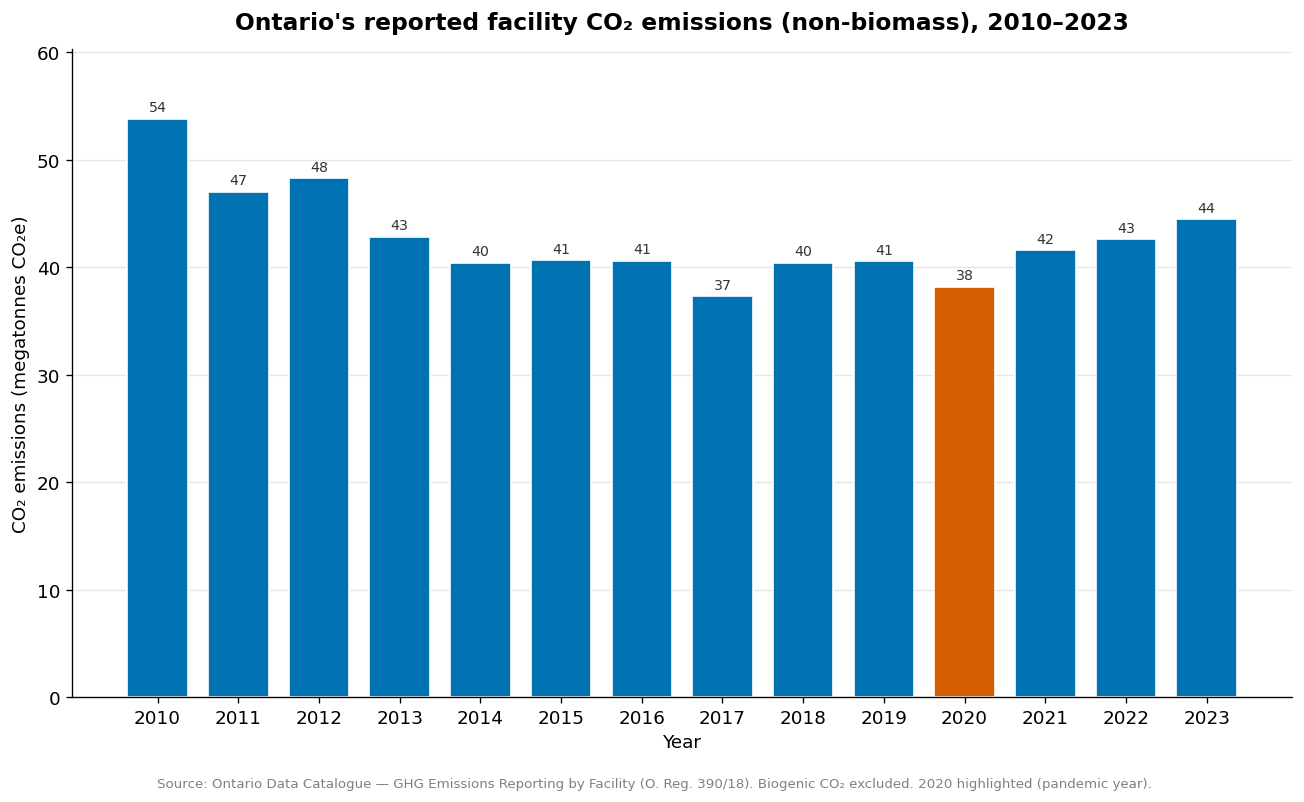

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))

# Draw the bars.
ax.bar(
    yearly_co2.index, yearly_co2.values,
    color=bar_colors, edgecolor="white", width=0.75,
)

# Add a value label above each bar.
for year, value in yearly_co2.items():
    ax.text(year, value + 0.4, f"{value:.0f}",
            ha="center", va="bottom", fontsize=8.5, color="#333333")

# Titles and axis labels
ax.set_title("Ontario's reported facility CO\u2082 emissions (non-biomass), 2010\u20132023",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("CO\u2082 emissions (megatonnes CO\u2082e)")
ax.set_xlabel("Year")

# X-axis: one tick per year.
ax.set_xticks(yearly_co2.index)
ax.set_xticklabels(yearly_co2.index)

# Headroom above the tallest bar so its label is not clipped.
ax.set_ylim(0, yearly_co2.max() * 1.12)

# De-clutter: remove top/right spines, add light horizontal gridlines behind bars.
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)

# Data-source / methodology note.
fig.text(0.125, -0.02,
         "Source: Ontario Data Catalogue \u2014 GHG Emissions Reporting by Facility "
         "(O. Reg. 390/18). Biogenic CO\u2082 excluded. 2020 highlighted (pandemic year).",
         fontsize=8, color="gray")

fig.tight_layout()
plt.show()

In [15]:
# Exporting the image to png
fig.savefig("ontario_co2_by_year_2010_2023.png", dpi=300, bbox_inches="tight")
print("Saved: ontario_co2_by_year_2010_2023.png")

Saved: ontario_co2_by_year_2010_2023.png
